## Prevendo a Ocorrência de Diabetes

## Conjunto de Dados do Repositório de Machine Learning da UCI / Kaggle
https://www.kaggle.com/uciml/pima-indians-diabetes-database/data

In [47]:
# Importando as bibliotecas
import pandas as pd                 
import seaborn as sns   
import numpy as np
import matplotlib.pyplot as plt

In [48]:
# Conjunto de Dados do Repositório de Machine Learning da UCI / Kaggle
df = pd.read_csv("diabete_em_indigenas.csv")
df.head()

,gravidezes,glicose,pressao_sangue,espessura,insulina,imc,diabete_p,idade,resultado
0,6,148,72,35,0,33.6,0.627,50,True
1,1,85,66,29,0,26.6,0.351,31,False
2,8,183,64,0,0,23.3,0.672,32,True
3,1,89,66,23,94,28.1,0.167,21,False
4,0,137,40,35,168,43.1,2.288,33,True


### Matriz de correlação

=== Criando o gráfico para Identificar a correlação entre as variáveis ===


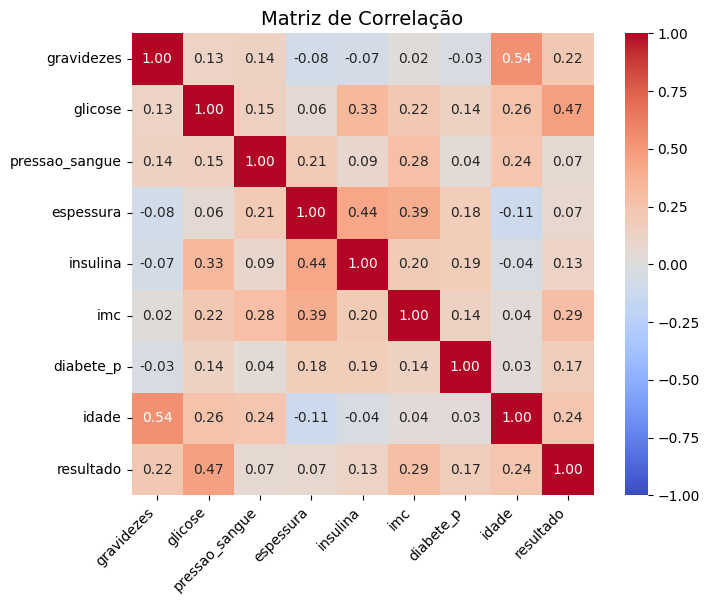

In [49]:
# A função corr() serve para calcular a correlação entre colunas numéricas. Indo -1 a 1
# Identificando a correlação entre as variáveis
def plot_corr(df):
    # Calcula a correlação das colunas
    corr = df.corr()

    plt.figure(figsize=(8, 6))

    # Cria o mapa de calor (heatmap)
    sns.heatmap(
        corr,
        annot=True,          # Mostra os valores dentro das células
        fmt=".2f",           # Formata os valores de dentro das células com 2 casas decimais
        cmap="coolwarm",     # Define qual é o mapa de cores
        square=True,         # Deixa as células quadradas
        cbar=True,           # Mostra barra de cores
        vmin=-1,             # Define o -1 como mínimo na escala da barra
        vmax=1,              # Define o 1 como o máximo na escala da barra
        center=0             # Define o 0 com centro
    )

    plt.title("Matriz de Correlação", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks()
    plt.show()

# Criando o gráfico
print("=== Criando o gráfico para Identificar a correlação entre as variáveis ===")
plot_corr(df)

In [50]:
# Visualizando a correlação em tabela
print("=== Coeficiente de correlação: ===" \
       "\n+1 = forte correlação positiva" \
       "\n 0 = não há correlação " \
       "\n-1 = forte correlação negativa")

df.corr()

=== Coeficiente de correlação: ===
+1 = forte correlação positiva
 0 = não há correlação 
-1 = forte correlação negativa


,gravidezes,glicose,pressao_sangue,espessura,insulina,imc,diabete_p,idade,resultado
gravidezes,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
glicose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressao_sangue,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
espessura,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulina,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
imc,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
diabete_p,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
idade,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
resultado,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [51]:
# Definindo as classes
resultado_map = {
    True : 1, 
    False : 0
}

# Aplicando o mapeamento ao dataset
df['resultado'] = df['resultado'].map(resultado_map)

# Verificando como os dados estão distribuídos
print("=== Verificando como os dados estão distribuídos ===")

# loc serve para selecionar e alterar dados por nomes
# Buscando os dados com valor True e False, depois contando a quantidade de ocorrência de cada um
num_true = len(df.loc[df['resultado'] == True])
num_false = len(df.loc[df['resultado'] == False])

# len(df.index) retorna o tamanho do dataframe
total = len(df.index)

print(f"Número de Casos Verdadeiros: {num_true} ({(num_true/total) * 100:.2f}%)")
print(f"Número de Casos Falsos: {num_false} ({(num_false/ total) * 100:.2f}%)")

=== Verificando como os dados estão distribuídos ===
Número de Casos Verdadeiros: 268 (34.90%)
Número de Casos Falsos: 500 (65.10%)


## Spliting

70% para dados de treino e 30% para dados de teste

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
# Seleção de variáveis preditoras (independentes)
atributos = ['gravidezes', 'glicose', 'pressao_sangue', 'espessura', 'insulina',
       'imc', 'diabete_p', 'idade']

# Variável a ser prevista (dependente)
atrib_prev = ['resultado']

In [54]:
# Criando objetos
# Criando arrays com os valores das colunas atributos em X e atrib_prev em Y
X = df[atributos].values
Y = df[atrib_prev].values

# Criando dados de treino e de teste
# Aqui estou dividindo os dados de X e Y em 70% treino, 30% teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = 0.30, random_state = 42)

# Imprimindo a porcentagem da divisão
print(f"{len(X_treino)/len(df.index) * 100:.2f}% nos dados de treino")
print(f"{len(X_teste)/len(df.index) * 100:.2f}% nos dados de teste")

69.92% nos dados de treino
30.08% nos dados de teste


## Construindo e treinando o modelo

In [55]:
from sklearn import metrics # Módulo com métricas de avaliação (accuracy, matriz de confusão..)
from sklearn.neural_network import MLPClassifier # Modelo de rede neural do tipo Multilayer Perceptron

In [ ]:
# Instanciando o modelo. MLPClassifier() é o modelo da rede neural
# random_state=42 fixa a aleatoriedade
modelo_v7 = MLPClassifier(random_state=42)
# aplicando o modelo nos dados de treino
modelo_v7.fit(X_treino, Y_treino.ravel()) # .ravel() transforma o vetor alvo em um array 1D


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


#### Método fit() serve para:
    Ajusta os pesos da rede
    Aprende padrões nos dados
    Minimiza o erro usando backpropagation
**.fit()** vai comparar as saidas obtidas no treino de X com as saídas esperadas guardadas em Y para melhorar o desempenho do modelo

In [57]:
# Aqui estou gerando previsões com o modelo
# Ele vai usar os valores de X para tentar prever as classes de Y
# Classes: 0 = não diabetes, 1 = diabetes
mlp_predict_train = modelo_v7.predict(X_treino)
mlp_predict_test = modelo_v7.predict(X_teste)

## Súmario

Verdadeiro positivo (true positive — TP)

Ocorre quando no conjunto real a classe que estamos buscando foi prevista corretamente. Por exemplo, quando a pessoa está com diabetes e o modelo previu corretamente que a pessoa está com diabetes.

Falso positivo (false positive — FP)

Ocorre quando no conjunto real a classe que estamos buscando prever foi prevista incorretamente. Exemplo: a pessoa não está com diabetes, mas o modelo disse que está.

Falso verdadeiro (true negative — TN)

Ocorre quando no conjunto real a classe que não estamos buscando prever foi prevista corretamente. Exemplo: a pessoa não estava com diabetes, e o modelo previu corretamente que ela não está.

Falso negativo (false negative — FN)

Ocorre quando no conjunto real, a classe que não estamos buscando prever foi prevista incorretamente. Por exemplo, quando a pessoa está com diabetes e o modelo previu incorretamente que ela não está com diabetes.

In [58]:
# tabela de orientação
tabela = pd.DataFrame(
    [["TP", "FP"],
     ["FN", "TN"]],
    columns=["Diabetes", "Não diabetes"],
    index=["Diabetes", "Não diabetes"]
)

In [59]:
# Comparando os valores que o modelo obteve no treino e no teste, com os valores reais de Y

# Calculando a porcentagem de acerto no treino e no teste
print("==================================================================================")
print(f"Exatidão (Accuracy) com os dados de treino do modelo MLPClassifier :\
 {metrics.accuracy_score(Y_treino, mlp_predict_train):.4f}")
print(f"Exatidão (Accuracy) com os dados de teste do modelo MLPClassifier:\
 {metrics.accuracy_score(Y_teste, mlp_predict_test):.4f}")

# O parâmetro labels=[1, 0] define a ordem que os dados vão aparecer
# Primeiro os dados que deram positivo(1) depois os dados negativos (0)

print("\nConfusion Matrix - Modelo MLPClassifier")
print(f"{metrics.confusion_matrix(Y_teste, mlp_predict_test, labels = [1, 0])}")
print(tabela)

print("\nClassification Report MLPClassifier")
print(metrics.classification_report(Y_teste, mlp_predict_test, labels = [1,0 ]))
print("==================================================================================")

Exatidão (Accuracy) com os dados de treino do modelo MLPClassifier : 0.7914
Exatidão (Accuracy) com os dados de teste do modelo MLPClassifier: 0.7229

Confusion Matrix - Modelo MLPClassifier
[[ 44  36]
 [ 28 123]]
             Diabetes Não diabetes
Diabetes           TP           FP
Não diabetes       FN           TN

Classification Report MLPClassifier
              precision    recall  f1-score   support

           1       0.61      0.55      0.58        80
           0       0.77      0.81      0.79       151

    accuracy                           0.72       231
   macro avg       0.69      0.68      0.69       231
weighted avg       0.72      0.72      0.72       231



## Usando o modelo na prática

In [60]:
# Função de predição para novos pacientes
def prever_diabetes(modelo, dados_paciente):
    """
    Faz predição de diabetes para um novo paciente
    
    Parâmetros:
    - modelo: modelo MLPClassifier treinado (modelo_v7)
    - dados_paciente: lista com 8 valores ['gravidezes', 'glicose', 'pressao_sangue', 'espessura',
                                            'insulina', 'imc', 'diabete_p', 'idade']
    
    Retorna:
    - Dicionário com resultado e probabilidades

    """
    
    # Converter para array numpy
    dados = np.array(dados_paciente).reshape(1, -1)
    
    # Fazer predição
    # modelo retorna um array, com o [0] pego o primeiro valor desse array
    predicao = modelo.predict(dados)[0]
    probabilidades = modelo.predict_proba(dados)[0]
    
    # o probabilidades = modelo.predict_proba(dados)[0] retorna um array de probabilidade assim [0.3, 0.7]
    # com [1] e [0] eu pego a probalidade para diabetes e não diabetes individualmente
    resultado = {
        'tem_diabetes': bool(predicao),
        'probabilidade_diabetes': probabilidades[1],
        'probabilidade_sem_diabetes': probabilidades[0],
        'classe_prevista': 'DIABETES' if predicao == 1 else 'SEM DIABETES'
    }
    
    return resultado

In [61]:
# Função para exibir resultado formatado
def exibir_resultado_predicao(resultado):
    """
    Exibe o resultado da predição de forma visual
    """
    print("=" * 60)
    print("                RESULTADO DA ANÁLISE DE DIABETES")
    print("=" * 60)
    
    if resultado['tem_diabetes']:
        print("RESULTADO: POSITIVO PARA DIABETES")
        print(f"    Probabilidade: {resultado['probabilidade_diabetes']:.2%}")
    else:
        print("RESULTADO: NEGATIVO PARA DIABETES")
        print(f"    Probabilidade de não ter diabetes: {resultado['probabilidade_sem_diabetes']:.2%}")
    
    print("-" * 60)
    print("DISTRIBUIÇÃO DE PROBABILIDADES:")
    print(f"    Sem diabetes: {resultado['probabilidade_sem_diabetes']:.2%}")
    print(f"    Com diabetes: {resultado['probabilidade_diabetes']:.2%}")
    print("=" * 60)
    
    print("                 IMPORTANTE \
    \nEste é um modelo preditivo para fins educacionais.\
    \nNão substitui diagnóstico médico profissional!")
    print("=" * 60 )

In [62]:
# Predição com dados fornecidos diretamente
print("EXEMPLO: Predição com dados fornecidos diretamente")

# Dados de exemplo
exemplo_paciente = [6, 148, 72, 35, 125, 33.6, 0.627, 50]

resultado = prever_diabetes(modelo_v7, exemplo_paciente)
exibir_resultado_predicao(resultado)

EXEMPLO: Predição com dados fornecidos diretamente
                RESULTADO DA ANÁLISE DE DIABETES
RESULTADO: POSITIVO PARA DIABETES
    Probabilidade: 56.49%
------------------------------------------------------------
DISTRIBUIÇÃO DE PROBABILIDADES:
    Sem diabetes: 43.51%
    Com diabetes: 56.49%
                 IMPORTANTE     
Este é um modelo preditivo para fins educacionais.    
Não substitui diagnóstico médico profissional!
